In [1]:
import h5py
import numpy as np
import pandas as pd

import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
!curl https://zenodo.org/records/2603256/files/train.h5?download=1 -o toptag_train.h5
!curl https://zenodo.org/records/2603256/files/val.h5?download=1 -o toptag_val.h5
!curl https://zenodo.org/records/2603256/files/test.h5?download=1 -o toptag_test.h5

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  990M  100  990M    0     0   9.9M      0  0:01:39  0:01:39 --:--:--  9.7M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  19.4M      0  0:00:17  0:00:17 --:--:-- 21.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  331M  100  331M    0     0  13.7M      0  0:00:24  0:00:24 --:--:-- 15.8M


In [3]:
fileIN_train = "toptag_train.h5"
fileIN_val = "toptag_val.h5"
fileIN_test = "toptag_test.h5"

f_train = h5py.File(fileIN_train)
# and see what it contains
print(list(f_train.keys()))

['table']


In [4]:
df_train = pd.read_hdf(fileIN_train, 'table')
df_val = pd.read_hdf(fileIN_val, 'table')
df_test = pd.read_hdf(fileIN_test, 'table')
df_train

,E_0,PX_0,PY_0,PZ_0,E_1,PX_1,PY_1,PZ_1,E_2,PX_2,...,E_199,PX_199,PY_199,PZ_199,truthE,truthPX,truthPY,truthPZ,ttv,is_signal_new
375,474.071136,-250.347031,-223.651962,-334.738098,103.236237,-48.866222,-56.790775,-71.025490,105.255569,-55.415001,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
377,150.504532,120.062393,76.852005,-48.274265,82.257057,63.801739,42.754807,-29.454842,48.573559,36.763199,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
378,251.645386,10.427651,-147.573746,203.564880,104.147797,10.718256,-54.497948,88.101395,78.043213,5.724113,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
379,451.566132,129.885437,-99.066292,-420.984100,208.410919,59.033958,-46.177090,-194.467941,190.183304,54.069675,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
380,399.093903,-168.432083,-47.205597,-358.717438,273.691956,-121.926941,-30.803854,-243.088928,152.837219,-44.400204,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,206.171997,13.942102,114.328499,-171.001465,231.602356,19.010832,92.303848,-211.561432,95.868248,0.411594,...,0.0,0.0,0.0,0.0,1301.364624,48.551048,674.270081,-1098.891968,0,1
591,263.984161,-40.649391,-104.321312,239.065552,238.690689,8.786323,-101.236137,215.979828,126.197868,5.939164,...,0.0,0.0,0.0,0.0,1550.415405,-38.385075,-626.145813,1406.682983,0,1
592,61.417538,42.901291,43.947723,-0.436818,45.521763,31.723654,32.643845,-0.469300,44.801167,29.730831,...,0.0,0.0,0.0,0.0,654.942383,394.933441,467.778076,-162.717285,0,1
593,261.215302,12.780115,-132.699203,224.635300,224.066376,52.028233,-101.145271,193.050354,67.573616,17.166769,...,0.0,0.0,0.0,0.0,1100.826904,220.153702,-566.737549,901.328003,0,1


In [5]:
# each row of the dataframe is a jet, each constituient is a particle, the only features are the four momentum
# Converting dataframe into a usable dataset for a transformer model
# add masking to ignore attention computation of paddings

def get_num_valid_particles(X):
    X_ = (X > 0)
    X_ = torch.sum(X_, 1)
    for i in range(X_.shape[-1]):
        if X_[i] <= 0:
            break
    return i

class JetDataset(Dataset):

    def __init__(self, df, start_top_jet = 0, top_num_jets = 200):

        self.jets = list()
        self.labels = list()
        # self.mask_indices = list()
        n = 0
        for index, row in df.iterrows():
            
            tensor = torch.tensor(row.values, dtype=torch.float)
            tensor_data = tensor[start_top_jet*4:top_num_jets*4].reshape(-1, 4)
    
            # terminal_idx = get_num_valid_particles(tensor_data)
            
            self.jets.append(tensor_data)
            self.labels.append(tensor[-1].item())
            # self.mask_indices.append(terminal_idx)
            
            n += 1
            
            if n % 10000 == 0:
                print(n)
                
    def __len__(self):
        return len(self.jets)

    def __getitem__(self, index):
        return self.jets[index], self.labels[index]# , self.mask_indices[index]


In [6]:
# constituent of each jet is ordered from large to small energy
start_top_jet = 5
top_num_jets = 35

dataset_train = JetDataset(df_train, start_top_jet, top_num_jets)
dataset_val = JetDataset(df_val, start_top_jet, top_num_jets)
dataset_test = JetDataset(df_test, start_top_jet, top_num_jets)

10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
220000
230000
240000
250000
260000
270000
280000
290000
300000
310000
320000
330000
340000
350000
360000
370000
380000
390000
400000
410000
420000
430000
440000
450000
460000
470000
480000
490000
500000
510000
520000
530000
540000
550000
560000
570000
580000
590000
600000
610000
620000
630000
640000
650000
660000
670000
680000
690000
700000
710000
720000
730000
740000
750000
760000
770000
780000
790000
800000
810000
820000
830000
840000
850000
860000
870000
880000
890000
900000
910000
920000
930000
940000
950000
960000
970000
980000
990000
1000000
1010000
1020000
1030000
1040000
1050000
1060000
1070000
1080000
1090000
1100000
1110000
1120000
1130000
1140000
1150000
1160000
1170000
1180000
1190000
1200000
1210000
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
180000
190000
200000
210000
22

In [7]:
class MAB(nn.Module):
    def __init__(self, dim_Q, dim_K, dim_V, num_heads, bias = True, ln=False):
        super(MAB, self).__init__()
        self.dim_V = dim_V
        self.num_heads = num_heads
        self.fc_q = nn.Linear(dim_Q, dim_V, bias = bias)
        self.fc_k = nn.Linear(dim_K, dim_V, bias = bias)
        self.fc_v = nn.Linear(dim_K, dim_V, bias = bias)
        if ln:
            self.ln0 = nn.LayerNorm(dim_V)
            self.ln1 = nn.LayerNorm(dim_V)
        self.fc_o = nn.Linear(dim_V, dim_V, bias = bias)
        
        self.history = dict()
        
    def forward(self, Q, K, mask=None):
        Q = self.fc_q(Q)
        K, V = self.fc_k(K), self.fc_v(K)
        
        self.history["Q"] = Q.detach().cpu()
        self.history["K"] = K.detach().cpu()
        self.history["V"] = V.detach().cpu()
        
        dim_split = self.dim_V // self.num_heads
        Q_ = torch.cat(Q.split(dim_split, 2), 0)
        K_ = torch.cat(K.split(dim_split, 2), 0)
        V_ = torch.cat(V.split(dim_split, 2), 0)
        
        A_pre = Q_.bmm(K_.transpose(1,2))/math.sqrt(self.dim_V)
        
        self.history["A"] = A_pre.detach().cpu()
        
        if mask is not None:
            mask = torch.full(tuple(A_pre.shape), -float('inf')).to(Q_.device)
            for idx, mask_id in enumerate(mask_idx):
                mask[idx, :mask_id, :mask_id] = 0
            A_pre += mask
        
        A = torch.softmax(A_pre, 2)
        O = torch.cat((Q_ + A.bmm(V_)).split(Q.size(0), 0), 2)
        O = O if getattr(self, 'ln0', None) is None else self.ln0(O)
        O = O + F.relu(self.fc_o(O))
        O = O if getattr(self, 'ln1', None) is None else self.ln1(O)
        return O

class SAB(nn.Module):
    def __init__(self, dim_in, dim_out, num_heads, ln=False, bias=True,):
        super(SAB, self).__init__()
        self.mab = MAB(dim_in, dim_in, dim_out, num_heads, ln=ln, bias=bias)

    def forward(self, X, mask=None):
        return self.mab(X, X, mask=mask)

# A one layer transformer (one self attention block)
class SetTransformer(nn.Module):
    def __init__(self, dim_input, dim_output, num_particles_per_jet, dim_hidden=64, num_heads=8, bias=True, ln=False):
        super(SetTransformer, self).__init__()
        self.enc = SAB(dim_input, dim_hidden, num_heads, ln=ln, bias=bias)
        self.pool = nn.AvgPool1d(num_particles_per_jet)
        self.norm = nn.BatchNorm1d(dim_hidden)
        self.fc = nn.Sequential(
            nn.Linear(dim_hidden,dim_output, bias = bias),
        )

    def forward(self, X, mask=None):
        X_ = self.pool(self.enc(X, mask=mask).transpose(1, 2)).squeeze(dim=-1)
        X_ = self.fc(self.norm(X_))
        return X_

In [8]:
torch.cuda.is_available()

True

In [9]:
# define model, dataloaders, optimizers, etc.
device = "cuda" if torch.cuda.is_available() else "cpu"

dim_in = 4
dim_output = 1
num_particles_per_jet = top_num_jets - start_top_jet
num_heads = 3
dim_hidden = 63
bias = False
model = SetTransformer(dim_in, dim_output, num_particles_per_jet, num_heads=num_heads, dim_hidden=dim_hidden, bias=bias).to(device)


'''
dataset_size = len(dataset)  # use a smaller number of datapoints for debugging
num_train = int(dataset_size * 0.8)
num_test = int(dataset_size * 0.1)
num_val = dataset_size - num_train - num_test

subset_indices_train = list(range(num_train))
subset_indices_val = list(range(num_train,num_train+num_val))
subset_indices_test = list(range(num_train+num_val, dataset_size))

train_subset = Subset(dataset, subset_indices_train)
val_subset = Subset(dataset, subset_indices_val)
test_subset = Subset(dataset, subset_indices_test)
'''

train_dataloader = DataLoader(dataset_train, batch_size=512, shuffle=True)
val_dataloader = DataLoader(dataset_val, batch_size=512, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=512, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

m = nn.Sigmoid()
mm = nn.BCELoss()

In [10]:
# training loop

epochs = 100
training_losses = []
eval_losses = []

for epoch in range(epochs):

    losses = []

    model.train()
    for batch in iter(train_dataloader):

        X, y = batch
        
        X = X.to(device)
        y = y.to(device)
        # mask_idx = list(mask_idx.detach().cpu().numpy())

        output = model(X).squeeze(dim=1).to(torch.float64)

        loss = mm(m(output), y)
                
        losses.append(loss.detach().cpu().item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}, train loss {sum(losses)/len(losses)}")
    training_losses.append(sum(losses)/len(losses))
    
    model.eval()
    val_losses = []
    with torch.no_grad():

        for batch in iter(val_dataloader):

            X, y = batch
            
            X = X.to(device)
            y = y.to(device)
        
            output = model(X).squeeze(dim=1).to(torch.float64)

            loss = mm(m(output), y)

            val_losses.append(loss.detach().cpu().item())

    print(f"Epoch {epoch}, val loss {sum(val_losses)/len(val_losses)}")
    eval_losses.append(sum(val_losses)/len(val_losses))
    

Epoch 0, train loss 0.5131297562514487
Epoch 0, val loss 0.4558389360617492


KeyboardInterrupt: 

In [13]:
model.enc.mab.history["Q"].shape

torch.Size([512, 30, 63])

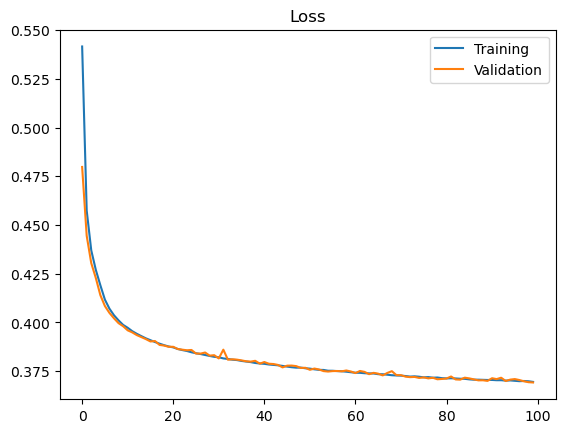

In [24]:
# loss plot

import matplotlib.pyplot as plt
fig,axes = plt.subplots(1)

axes.plot(training_losses)
axes.plot(eval_losses)
axes.legend(["Training", "Validation"])
axes.set_title("Loss")

fig.show()

Test set loss: 0.3666295467358216
Test accuracy: 0.8472722772277228


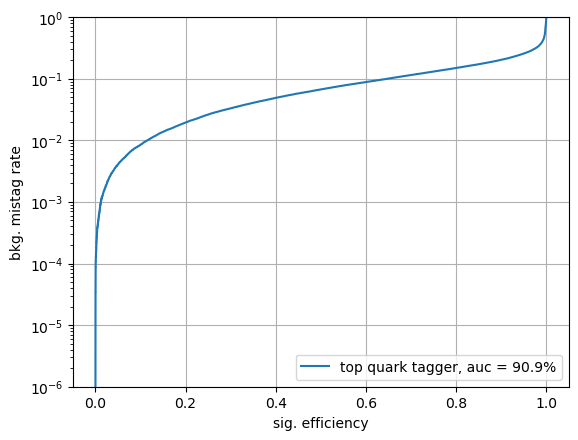

In [25]:
# testing on test set

model.eval()

test_losses = []
test_logits = []
test_labels_true = []
test_num_correct = 0
with torch.no_grad():

    for batch in iter(test_dataloader):

        X, y = batch
        
        X = X.to(device)
        y = y.to(device)
        
        output = model(X).squeeze(dim=1).to(torch.float64)
        probs = m(output)
        
        predicted_labels = (probs >= 0.5)

        loss = mm(probs, y)

        test_labels_true.extend(list(y.to(torch.long).detach().cpu().numpy()))
        test_logits.extend(list(output.detach().cpu().numpy()))
        test_losses.append(loss.item())
        test_num_correct += torch.sum(y == predicted_labels).item()

print(f"Test set loss: {sum(test_losses)/len(test_losses)}")
print(f"Test accuracy: {test_num_correct / len(dataset_test)}")

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc

df = pd.DataFrame()
fpr = {}
tpr = {}
auc1 = {}

plt.figure()

fpr, tpr, threshold = roc_curve(np.array(test_labels_true), np.array(test_logits))

auc1 = auc(fpr, tpr)

plt.plot(tpr,fpr,label='%s tagger, auc = %.1f%%'%("top quark",auc1*100.))

plt.semilogy()
plt.xlabel("sig. efficiency")
plt.ylabel("bkg. mistag rate")
plt.ylim(0.000001,1)
plt.grid(True)
plt.legend(loc='lower right')
plt.show()


In [13]:
# Saving model
PATH = "./1layer_set_transformer_topquarktag_reducedmlp_3heads_nobias.pt"
torch.save(model.state_dict(), PATH)